<a href="https://colab.research.google.com/github/RytisBalt/DI-kursas/blob/Dirbtinis2/DirbtinisNr2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

iris = pd.read_csv('/content/iris.data', header=None)
iris = iris.iloc[50:150]

iris.columns = ['sepal length', 'sepal width', 'petal length', 'petal width', 'class']
class_mapping = {
    'Iris-versicolor': 0,
    'Iris-virginica': 1
}
iris['class'] = iris['class'].map(class_mapping)

iris_shuffled = iris.sample(frac=1)

print(iris_shuffled)



     sepal length  sepal width  petal length  petal width  class
111           6.4          2.7           5.3          1.9      1
115           6.4          3.2           5.3          2.3      1
135           7.7          3.0           6.1          2.3      1
142           5.8          2.7           5.1          1.9      1
119           6.0          2.2           5.0          1.5      1
..            ...          ...           ...          ...    ...
59            5.2          2.7           3.9          1.4      0
139           6.9          3.1           5.4          2.1      1
61            5.9          3.0           4.2          1.5      0
109           7.2          3.6           6.1          2.5      1
84            5.4          3.0           4.5          1.5      0

[100 rows x 5 columns]


In [ ]:
import numpy as np
breast_cancer = pd.read_csv('/content/breast-cancer-wisconsin.data', header = None)
breast_cancer.columns = [
    'Sample code number', 'Clump Thickness', 'Uniformity of Cell Size',
    'Uniformity of Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size',
    'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', 'Mitoses', 'Class'
]
class_mapping = {
    2: 0,
    4: 1,

}
breast_cancer['Class'] = breast_cancer['Class'].map(class_mapping)
breast_cancer = breast_cancer.drop('Sample code number', axis=1)
breast_cancer.replace('?', np.nan, inplace = True)
breast_cancer.dropna(inplace = True)
breast_cancer['Bare Nuclei'] = pd.to_numeric(breast_cancer['Bare Nuclei'])
bc_shuffled = breast_cancer.sample(frac=1)
bc_shuffled

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
402,5,3,3,1,2,1,2,1,1,0
232,8,4,6,3,3,1,4,3,1,0
272,3,3,5,2,3,10,7,1,1,1
401,3,1,1,1,2,1,1,1,1,0
646,1,2,2,1,2,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...
74,10,6,4,1,3,4,3,2,3,1
541,3,1,1,1,2,1,1,1,1,0
135,5,1,1,1,2,2,3,3,1,0
648,5,10,10,10,10,2,10,10,10,1


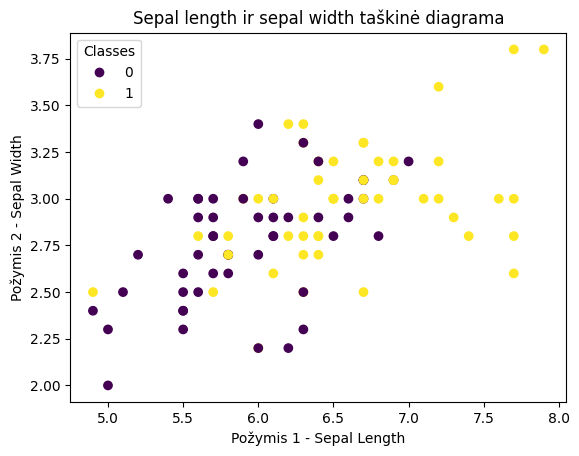

In [ ]:
import matplotlib.pyplot as plt


scatter = plt.scatter(iris_shuffled["sepal length"], iris_shuffled['sepal width'],
                      c=iris_shuffled['class'])

plt.xlabel('Požymis 1 - Sepal Length')
plt.ylabel('Požymis 2 - Sepal Width')
plt.title('Sepal length ir sepal width taškinė diagrama')
legend_labels = ['Class 0', 'Class 1']
plt.legend(*scatter.legend_elements(),
                    loc="upper left", title="Classes")


plt.show()

In [ ]:
!pip install imblearn

Klasių pasiskirstymas po SMOTE:
class
1    200
0    200
Name: count, dtype: int64


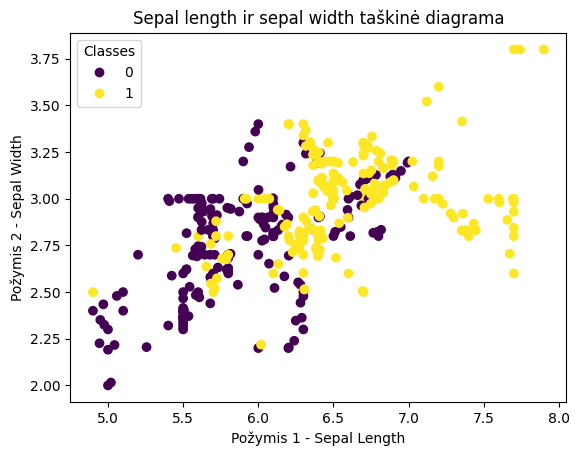

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy={0: 200, 1: 200})
features = iris_shuffled.drop('class', axis=1)
target = iris_shuffled['class']

X_resampled, y_resampled = smote.fit_resample(features, target)

resampled_iris_data = pd.DataFrame(X_resampled, columns=features.columns)
resampled_iris_data['class'] = y_resampled

print("Klasių pasiskirstymas po SMOTE:")
print(resampled_iris_data['class'].value_counts())
resampled_iris_data

scatter = plt.scatter(resampled_iris_data["sepal length"], resampled_iris_data['sepal width'],
                      c=resampled_iris_data['class'])

plt.xlabel('Požymis 1 - Sepal Length')
plt.ylabel('Požymis 2 - Sepal Width')
plt.title('Sepal length ir sepal width taškinė diagrama')
legend_labels = ['Class 0', 'Class 1']
plt.legend(*scatter.legend_elements(),
                    loc="upper left", title="Classes")


plt.show()


In [ ]:
def slenkstine(x):
  if x >=0:
    return 1
  return 0

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
X = resampled_iris_data[['sepal length', 'sepal width', 'petal length', 'petal width']].values
y = resampled_iris_data['class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Xb = bc_shuffled[['Clump Thickness', 'Uniformity of Cell Size',
    'Uniformity of Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size',
    'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', 'Mitoses']].values
yb = bc_shuffled['Class'].values

scaler = MinMaxScaler()
Xb = scaler.fit_transform(Xb)


Xb_train, Xb_test, yb_train, yb_test = train_test_split(Xb, yb, test_size=0.2)



In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.utils import shuffle

def Adaline(Input, Target, eta, epochs, Emin):

    weight = np.random.random(Input.shape[1])
    bias = np.random.random()
    totalError = 1000
    epoch = 0
    error_list = []
    accuracy_list = []

    while totalError > Emin and epoch < epochs:
        totalError = 0
        Input_shuffled, Target_shuffled = shuffle(Input, Target)
        for i in range(Input.shape[0]):
            Y_input = np.dot(weight, Input_shuffled[i]) + bias

            for j in range(Input.shape[1]):
                weight[j] = weight[j] + eta * (Target_shuffled[i] - Y_input) * Input_shuffled[i][j]
            bias = bias + eta * (Target_shuffled[i] - Y_input)

            error = (Target_shuffled[i] - Y_input) ** 2
            totalError += error
        epoch += 1

        y_train_pred = np.dot(Input, weight) + bias
        y_train_pred = [slenkstine(x) for x in y_train_pred]

        accuracy = accuracy_score(Target, y_train_pred)

        print(f"Epocha {epoch}/{epochs}, Total Error: {totalError}, Tikslumas: {accuracy}")
        error_list.append(totalError)
        accuracy_list.append(accuracy)


    return weight, bias, error_list, accuracy_list

weights, bias, error_lost, accuracy_lost = Adaline(X_train, y_train, eta=0.02, epochs=10, Emin=0.01)
print(f"Final Weights: {weights}, Final Bias: {bias}")


Epocha 1/10, Total Error: 120.6441547049128, Tikslumas: 0.571875
Epocha 2/10, Total Error: 89.89081391810173, Tikslumas: 0.68125
Epocha 3/10, Total Error: 68.49334679112296, Tikslumas: 0.559375
Epocha 4/10, Total Error: 61.51897194427635, Tikslumas: 0.965625
Epocha 5/10, Total Error: 76.7782551337721, Tikslumas: 0.8375
Epocha 6/10, Total Error: 70.03110014609615, Tikslumas: 0.9125
Epocha 7/10, Total Error: 77.56121298245122, Tikslumas: 0.928125
Epocha 8/10, Total Error: 87.29382934664714, Tikslumas: 0.51875
Epocha 9/10, Total Error: 63.605533961587504, Tikslumas: 0.546875
Epocha 10/10, Total Error: 62.97402982026345, Tikslumas: 0.50625
Final Weights: [-0.15139074 -0.40766711  0.49451719  0.80291387], Final Bias: -0.07703883352190305


In [ ]:

def prediction(X_test, weights, bias):
    y_pred = np.dot(X_test, weights) + bias
    y_pred = [slenkstine(x) for x in y_pred]
    return np.array(y_pred)
y_pred = prediction(X_test, weights, bias)

X_test = pd.DataFrame(X_test, columns=['sepal length', 'sepal width', 'petal length', 'petal width'])
X_test['Actual Class'] = y_test
X_test['Predicted Class'] = y_pred
X_test


,sepal length,sepal width,petal length,petal width,Actual Class,Predicted Class
0,5.500000,2.600000,4.400000,1.200000,0,0
1,6.538454,2.869227,5.565387,2.165387,1,1
2,5.621608,2.743216,4.200000,1.300000,0,0
3,5.500000,2.466452,4.000000,1.300000,0,0
4,6.785015,3.014985,5.514985,2.144956,1,1
...,...,...,...,...,...,...
75,5.679543,2.700000,4.160228,1.180685,0,0
76,5.600000,2.900000,3.600000,1.300000,0,0
77,6.753271,3.153271,5.759814,2.346729,1,1
78,7.673640,2.705439,6.820921,2.247281,1,1


In [ ]:
def mse(y_pred, y_test):
    squared_error = (y_pred - y_test) ** 2
    sse = np.sum(squared_error)
    loss = sse / y_test.size
    return loss


mse_value = mse(np.array(y_pred), np.array(y_test))
print("MSE:", mse_value)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc}")


MSE: 0.05
Test Accuracy: 0.95


In [ ]:
weights, bias, error_lost, accuracy_lost = Adaline(Xb_train, yb_train, eta=0.001, epochs=10, Emin=0.01)
print(f"Final Weights: {weights}, Final Bias: {bias}")

Epocha 1/10, Total Error: 289.18748144673447, Tikslumas: 0.6043956043956044
Epocha 2/10, Total Error: 90.03866780479775, Tikslumas: 0.8205128205128205
Epocha 3/10, Total Error: 55.83296874801219, Tikslumas: 0.8553113553113553
Epocha 4/10, Total Error: 46.32722802531583, Tikslumas: 0.8516483516483516
Epocha 5/10, Total Error: 41.724392051691176, Tikslumas: 0.8315018315018315
Epocha 6/10, Total Error: 38.70900962581009, Tikslumas: 0.815018315018315
Epocha 7/10, Total Error: 36.522170988332135, Tikslumas: 0.7838827838827839
Epocha 8/10, Total Error: 34.877785286037046, Tikslumas: 0.7637362637362637
Epocha 9/10, Total Error: 33.57154678343438, Tikslumas: 0.7435897435897436
Epocha 10/10, Total Error: 32.52013383144538, Tikslumas: 0.6959706959706959
Final Weights: [ 0.1808943  -0.01845337  0.61589397  0.45583846  0.33295585  0.19793832
  0.06870014 -0.16438314  0.37186218], Final Bias: -0.10781469650192434


In [ ]:
yb_pred = prediction(Xb_test, weights, bias)
Xb_test = pd.DataFrame(Xb_test, columns=['Clump Thickness', 'Uniformity of Cell Size',
    'Uniformity of Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size',
    'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', 'Mitoses'])
Xb_test['Actual Class'] = yb_test
Xb_test['Predicted Class'] = yb_pred
Xb_test

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Actual Class,Predicted Class
0,0.444444,0.000000,0.000000,0.111111,0.000000,0.000000,0.111111,0.000000,0.000000,0,1
1,0.444444,0.333333,0.555556,0.666667,0.888889,0.666667,0.777778,1.000000,0.000000,1,1
2,0.444444,0.000000,0.111111,1.000000,0.333333,0.444444,0.111111,0.000000,0.000000,0,1
3,0.888889,0.444444,0.444444,0.333333,0.333333,0.444444,0.333333,0.222222,0.222222,1,1
4,0.777778,1.000000,0.222222,0.111111,0.555556,0.333333,0.222222,1.000000,0.000000,1,1
...,...,...,...,...,...,...,...,...,...,...,...
132,0.666667,0.444444,0.222222,0.666667,0.333333,1.000000,0.666667,0.444444,0.444444,1,1
133,0.777778,1.000000,1.000000,0.777778,0.444444,1.000000,0.666667,0.777778,0.000000,1,1
134,0.444444,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1,1
135,0.222222,0.000000,0.000000,0.222222,0.000000,0.000000,0.222222,0.000000,0.000000,0,1


In [ ]:
mse_value = mse(np.array(yb_pred), np.array(yb_test))
print("MSE:", mse_value)
acc = accuracy_score(yb_test, yb_pred)
print(f"Test Accuracy: {acc:.4f}")

MSE: 0.35766423357664234
Test Accuracy: 0.6423


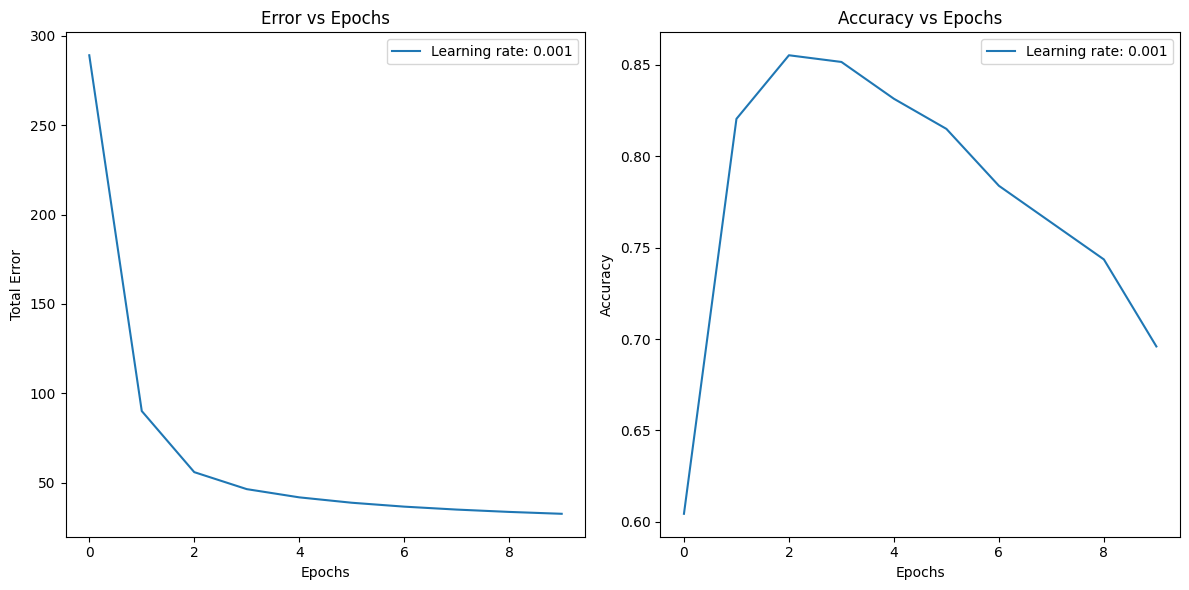

In [ ]:
def plot_results(epochs, errors, accuracies, learning_rate):
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(range(epochs), errors, label=f"Learning rate: {learning_rate}")
    plt.xlabel('Epochs')
    plt.ylabel('Total Error')
    plt.title('Error vs Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(epochs), accuracies, label=f"Learning rate: {learning_rate}")
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Epochs')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_results(10, error_lost, accuracy_lost, 0.001)

